# rSNAPsim example usages

![](../docs/images/flowchart.png)


rSNAPsim is a open source Nascent Chain Tracking (NCT) simulation and analyses software written in Python. Current version 2.0 is still under development! So please excuse any temporary bugs.



In [ ]:
import os
print(os.getcwd())
cwd = os.getcwd()
os.chdir('../../')
import rsnapsim as rsnp  # import the rsnapsim
os.chdir(cwd)
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from matplotlib import cm

## Loading in a sequence file to run NCT simulations 

The core of rSNAPsim is a TASEP based mRNA translation model that encorporates fluorescent probe tracking. 

![](../docs/images/tasep_base.png)

A Totally Asymmetric Simple Exclusion Process is a model that simulates particle motion along a lattice of nodes with exclusion (volumetric properties). Ribosomes undering going mRNA translation are directly analogous to this model when using a particle size of 9 lattice nodes (codons) and a codon dependent stepping rate. 

rSNAPsim allows the user to quickly load nucleotide sequence and convert it to stepping rates for a TASEP model.


In [36]:
# load a sequence file
# When we load a sequence file, several objects are returned:

# aaseq_dict - a dictionary of detected orfs reported as their amino acid sequences, keyed by frame
# cds_dict - a dictionary of detected orfs converted to CDS objects keyed by frame
# tagged_cdss - a dictionary of detected orfs with known fluorescent epitopes
# source_seq - a single string of the raw sequence pulled from the file

# this protein plasmid is from yersinia pestis (plague) you can see the original NCBI genbank file here: https://www.ncbi.nlm.nih.gov/nuccore/NC_005816
aaseq_dict, cds_dict, tagged_cdss, source_seq = rsnp.seqmanip.open_seq_file('../gene_files/NC_005816.gb', add_tag=False)

In [37]:
# The CDS objects are a single open reading frame that is larger than 80 codons by default. A CDS object stores everything you need to run a 
# quick simulation.
cds_dict

{'0': [<rsnapsim.cds.CDS at 0x1a4442748f0>],
 '+1': [<rsnapsim.cds.CDS at 0x1a44b1d1d90>,
 '+2': [<rsnapsim.cds.CDS at 0x1a44b269370>,
 '-1': [<rsnapsim.cds.CDS at 0x1a44af136e0>,
  <rsnapsim.cds.CDS at 0x1a44ae64c80>]}

Now that we have opened a sequence file, you can see that we have multiple coding regions (CDS) to choose from in multiple frames. We have to pick a CDS region to simulate translation with, 

In [5]:
# Lets look at how many valid coding regions were detected: 
cds_count = [len(cds_dict[x]) for x in ['0','+1','-1']]
print('cds count in the  %s frame: %i'%('0',cds_count[0]))
print('cds count in the %s frame: %i'%('+1',cds_count[1]))
print('cds count in the %s frame: %i'%('-1',cds_count[2]))


cds count in the  0 frame: 1
cds count in the +1 frame: 3
cds count in the -1 frame: 4


In [6]:
# lets take a look at what a CDS object contains
cds_dict['0'][0].__dict__

{'aa_seq': 'MKKSSIVATIITILSGSANAASSQLIPNISPDSFTVAASTGMLSGKSHEMLYDAETGRKISQLDWKIKNVAILKGDISWDPYSFLTLNARGWTSLASGSGNMDDYDWMNENQSEWTDHSSHPATNVNHANEYDLNVKGWLLQDENYKAGITAGYQETRFSWTATGGSYSYNNGAYTGNFPKGVRVIGYNQRFSMPYIGLAGQYRINDFELNALFKFSDWVRAHDNDEHYMRDLTFREKTSGSRYYGTVINAGYYVTPNAKVFAEFTYSKYDEGKGGTQIIDKNSGDSVSIGGDAAGISNKNYTVTAGLQYRF*',
 'nt_seq': 'AUGAAGAAAAGUUCUAUUGUGGCAACCAUUAUAACUAUUCUGUCCGGGAGUGCUAAUGCAGCAUCAUCUCAGUUAAUACCAAAUAUAUCCCCUGACAGCUUUACAGUUGCAGCCUCCACCGGGAUGCUGAGUGGAAAGUCUCAUGAAAUGCUUUAUGACGCAGAAACAGGAAGAAAGAUCAGCCAGUUAGACUGGAAGAUCAAAAAUGUCGCUAUCCUGAAAGGUGAUAUAUCCUGGGAUCCAUACUCAUUUCUGACCCUGAAUGCCAGGGGGUGGACGUCUCUGGCUUCCGGGUCAGGUAAUAUGGAUGACUACGACUGGAUGAAUGAAAAUCAAUCUGAGUGGACAGAUCACUCAUCUCAUCCUGCUACAAAUGUUAAUCAUGCCAAUGAAUAUGACCUCAAUGUGAAAGGCUGGUUACUCCAGGAUGAGAAUUAUAAAGCAGGUAUAACAGCAGGAUAUCAGGAAACACGUUUCAGUUGGACAGCUACAGGUGGUUCAUAUAGUUAUAAUAAUGGAGCUUAUACCGGAAACUUCCCGAAAGGAGUGCGGGUAAUAGGUUAUAACCAGCGCUUUUCUAUGCCAUAUAUUGGACUUGCAGGCCAGUAUCGCAUUAAUGAUUUUGAGUUAAAUGCAUUAUUUAAAUUCAGCGACUGGGUU

In [7]:
# how large is each open reading frame?
[[len(x.aa_seq) for x in cds_dict[y]] for y in ['0','+1','-1']]

[[313], [260, 146, 139], [341, 89, 81, 93]]

In [8]:
# lets simulate translation using the largest coding region. 
largest_CDS = cds_dict['+2'][0]

In [9]:
largest_CDS.aa_seq #heres the amino acid sequence of our protein

'MVTFETVMEIKILHKQGMSSRAIARELGISRNTVKRYLQAKSEPPKYTPRPAVASLLDEYRDYIRQRIADAHPYKIPATVIAREIRDQGYRGGMTILRAFIRSLSVPQEQEPAVRFETEPGRQMQVDWGTMRNGRSPLHVFVAVLGYSRMLYIEFTDNMRYDTLETCHRNAFRFFGGVPREVLYDNMKTVVLQRDAYQTGQHRFHPSLWQFGKEMGFSPRLCRPFRAQTKGKVERMVQYTRNSFYIPLMTRLRPMGITVDVETANRHGLRWLHDVANQRKHETIQARPCDRWLEEQQSMLALPPEKKEYDVHLDENLVNFDKHPLHHPLSIYDSFCRGVA*'

## Solving simulated translation trajectories

In [69]:
# how do we solve a model?
rsnp.solver.solve_ssa?

# Currently the model solver takes 3 types of inputs: A custom model object, a CDS object, or a simple list of stepping rates
# If a list is provided, the additional arguments of ki, kt, and probe list (list of lists of locations) are required.

Signature:
rsnp.solver.solve_ssa(
    mRNA_model,
    t,
    n_traj=1,
    burnin=0,
    seed=None,
    parallel=False,
    cplus=False,
    cores=4,
    probe_list=None,
    ki=None,
    kt=None,
)
Docstring: <no docstring>
File:      c:\users\willi\documents\github\rsnapsim\rsnapsim\solver.py
Type:      method

In [70]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(largest_CDS, t)

Our solution stores the agent array of our simulation in the shape of Number of trajectories by time by maximum ribosomes by agent attribute size.

In our case it should be (1 trajectory, 10001 time points, 42 maximum ribosomes at a time, 7 attributes)

In [49]:
soln.ribosome_array.shape # ribosomal movement array N_traj x time x max_ribosomes

(1, 10001, 42, 7)

Let's plot the particle movement, for this let's define a quick function. ```ribosome_array[:, :, :, 3]``` is the location of the agents in the codon direction.

In [71]:
# Function to plot a kymograph
def plot_kymograph(ribosome_array):
    fig,ax = plt.subplots(1,1)
    c = ax.plot(t, ribosome_array[:,:,3] ,'r.',markersize=1)
    newx = [x.get_xdata() for x in c]
    newy =  [x.get_ydata() for x in c]
    [c[x].set_xdata(newy[x]) for x in range(len(c))]
    [c[x].set_ydata(newx[x]) for x in range(len(c))]
    ax.set_title('Kymograph of one Simulation Trajectory')
    ax.set_xlabel('Codon')
    ax.set_ylabel('Time (s)')
    ax.set_xlim([0,max(newy[0])])
    ax.set_ylim([0,max(newx[0])])
    ax.invert_yaxis()

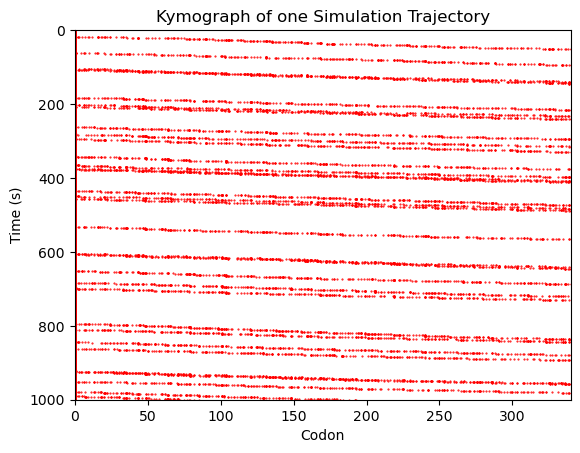

In [72]:
# Lets plot the motion of the ribosome
plot_kymograph(soln.ribosome_array[0])

In [54]:
# Where do the default rates come from? Can we change them?
largest_CDS.kelong_mat

array([[14.73279406,  9.71025063,  8.77270919, ..., 18.81779605,
         4.95557618,  1.07147593],
       [ 0.        ,  8.83967644,  8.17000398, ..., 26.51902931,
         8.83967644,  3.01352606],
       [ 0.        ,  8.83967644,  8.17000398, ..., 26.51902931,
         8.83967644,  3.01352606]])

You may have noticed we ran this simulation without explicitly defining these stepping rates from codon to condon. As a default, the Nakamura 2000 values of codon frequencies per 1000 codons to scale "fast" and "slow" codons to a desired average rate.

$k_e(i) = \bar{k_e}*(u(i)/\bar{u})$

Where $k_e(i)$ of the $i^{th}$ codon is equal to an average $\bar{k_e}$ times the ratio of the $u(i)$ codon frequency of the $i^{th}$ codon to the average codon frequency across the dictionary.

We can use a different dictionary, or our own dictionary as long as we cover every codon in a given sequence. Here we are going to replace the stepping rates with a different human codon frequency dictionary scaled to a mean of 2 codons per second.

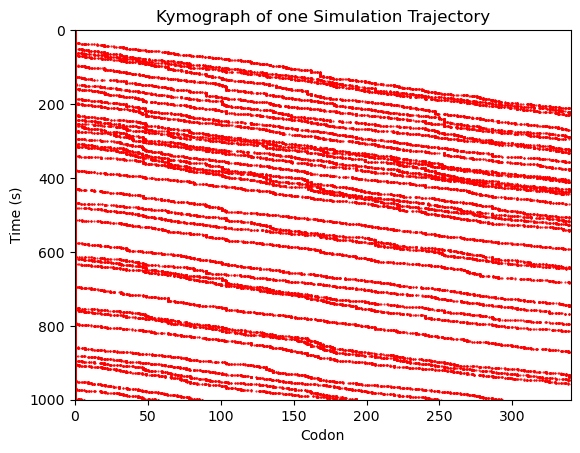

In [73]:
k_initiation = .03
k_termination = 10
stepping_rate_mean = 2

# generate a stepping rate list with the propensity_factory (propf)
stepping_rate_list = rsnp.propf.get_k(largest_CDS.nt_seq.replace('U','T'),
                                      k_initiation, stepping_rate_mean, k_termination, codon_freq_bias_dict=rsnp.aux_cdict.Human_codon_freq_HIVE)[1:-1]

t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(stepping_rate_list, t, probe_list = [], ki = k_initiation, kt=k_termination)

plot_kymograph(soln.ribosome_array[0])

We can also generate a list and edit it manually, then solve TASEP trajectories with those rates.

# Manually induce a pause at the 100th codon!

stepping_rate_list = largest_CDS.kelong
stepping_rate_list[100] = .05
stepping_rate_list[-1] = 0
t = np.linspace(0,1000,10001)

k_initiation = .03
k_termination = 10
soln = rsnp.solver.solve_ssa(stepping_rate_list, t, probe_list = [], ki = k_initiation, kt=k_termination)

plot_kymograph(soln.ribosome_array[0])

## What about the intensity trajectories?

So far we have only looked at ribosomal movement, but in the real world our data is given as the calculated intensity of a given mRNA spot over time. To calculate this from our simulations, we need to give it locations of the fluorescent epitopes so it can sum an intensity as ribosomes pass this codon.

In [19]:
soln.intensity_arr.sum() #hang on theres no intensity? Yes because we didn't tag it with any fluorescent epitopes!

0

In [20]:
rsnp.cdict.tag_dict # Here are some of our tagging options

{'T_SunTag': 'EELLSKNYHLENEVARLKK',
 'T_Flag': 'DYKDDDDK',
 'T_Hemagglutinin': 'YPYDVPDYA',
 'T_Myc': 'EQKLISEEDL',
 'T_Strep': 'WSHPQFEK',
 'T_Hist': 'HHHHHH',
 'T_V5': 'GKPIPNPLLGLDST',
 'T_TC': 'CCPGCC'}

Here we are going to make a new CDS object that has a full 10X FLAG tag appended on the front of the protein.

In [21]:
rsnp.cdict.tag_full['T_Flag'] #lets add a full 10x tflag

'ATGGACTACAAGGACGACGACGACAAAGGTGACTACAAAGATGATGACGATAAAGGCGACTATAAGGACGATGACGACAAGGGCGGAAACTCACTGATCAAGGAAAACATGCGGATGAAGGTGGTGATGGAGGGCTCCGTGAATGGTCACCAGTTCAAGTGCACCGGAGAGGGAGAGGGAAACCCGTACATGGGAACTCAGACCATGCGCATTAAGGTCATCGAAGGAGGTCCGCTGCCGTTCGCTTTCGATATCCTGGCCACTTCGTTCGGAGGAGGGTCGCGCACGTTCATCAAGTACCCGAAGGGAATCCCGGACTTCTTTAAGCAGTCATTCCCGGAAGGATTCACTTGGGAACGGGTGACCCGGTATGAAGATGGAGGTGTGGTGACTGTCATGCAAGATACTTCGCTGGAGGATGGGTGCCTCGTGTACCACGTCCAAGTCCGCGGAGTGAATTTCCCGTCCAACGGACCAGTGATGCAGAAAAAGACGAAGGGTTGGGAACCTAATACTGAAATGATGTACCCCGCAGACGGAGGGCTGAGGGGCTACACCCACATGGCGCTGAAGGTCGACGGAGGAGATTACAAGGATGACGACGATAAGCAACAAGATTACAAAGACGATGATGACAAGGGCCAGCAGGGCGACTACAAGGACGACGACGACAAGCAGCAGGACTACAAAGATGACGATGATAAAGGAGGAGGACATCTGTCCTGTTCGTTCGTGACCACCTACAGATCAAAGAAAACCGTGGGAAACATCAAGATGCCGGGCATTCATGCCGTCGACCACCGCCTGGAGCGGCTCGAAGAATCAGACAATGAGATGTTCGTCGTGCAAAGAGAACATGCCGTGGCCAAGTTCGCGGGACTGGGAGGCGGTGGAGGCGATTACAAAGACGATGATGACAAGGGTGACTATAAAGACGACGATGACAAAGGGGATTACAAGGATGATGATGATAAGGGAGGCGGTGGATCAGGTGGAGGA

In [22]:
rsnp.seqmanip.nt2aa(rsnp.cdict.tag_full['T_Flag'])

'MDYKDDDDKGDYKDDDDKGDYKDDDDKGGNSLIKENMRMKVVMEGSVNGHQFKCTGEGEGNPYMGTQTMRIKVIEGGPLPFAFDILATSFGGGSRTFIKYPKGIPDFFKQSFPEGFTWERVTRYEDGGVVTVMQDTSLEDGCLVYHVQVRGVNFPSNGPVMQKKTKGWEPNTEMMYPADGGLRGYTHMALKVDGGDYKDDDDKQQDYKDDDDKGQQGDYKDDDDKQQDYKDDDDKGGGHLSCSFVTTYRSKKTVGNIKMPGIHAVDHRLERLEESDNEMFVVQREHAVAKFAGLGGGGGDYKDDDDKGDYKDDDDKGDYKDDDDKGGGGSGGGGSLQ'

In [23]:
newseq = rsnp.cdict.tag_full['T_Flag'] + largest_CDS.nt_seq
tagged_CDS = rsnp.seqmanip.seq_to_CDS_obj(newseq)['0'][0] 
tagged_CDS.generate_3frame_tags()

Text(0, 0.5, 'probe value')

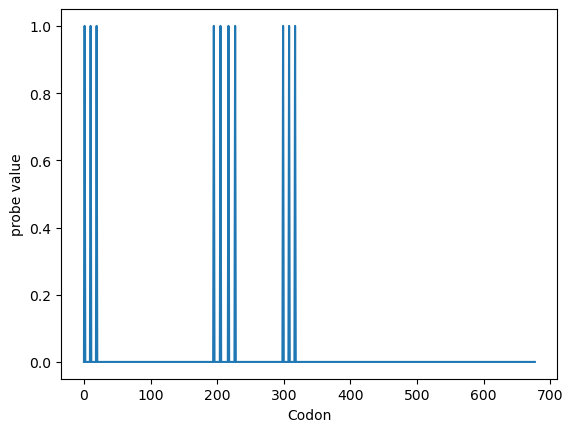

In [79]:
plt.plot(tagged_CDS.probe_mat[0,:])
plt.xlabel('Codon')
plt.ylabel('probe value')

In [80]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(tagged_CDS, t)

In [26]:
soln.intensity_arr.sum() #now we should have intensity

135846

Text(0, 0.5, 'Intensity (# probes)')

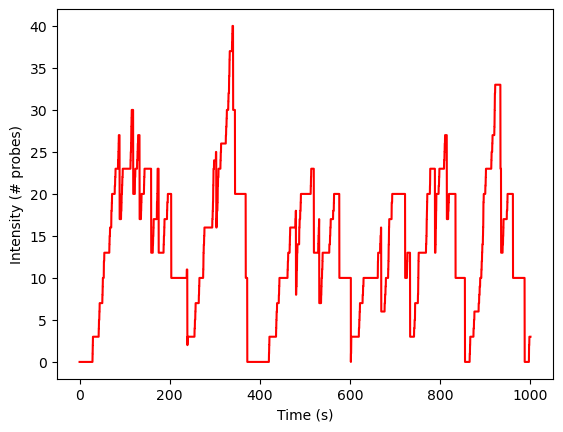

In [27]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')

## Custom TASEP models

A new feature of the rSNAPsim version 2.0 is a custom TASEP modeler. We wont go into full detail here, but we can show a couple example models. Almost every possible reaction and interaction is available to be customized by the user. The goal of this module is to be able to quickly generate and explore models for a bunch of translation dynamics!

![](../docs/images/mRNA_translation_dynamics.png)

For example, lets add an alternate start site at codon 100

In [90]:
mRNA_length = len(tagged_CDS.kelong) 
model = rsnp.tasep_model(tagged_CDS, 'test') # model object

## overwite the default kelongation matrix 
kelong_mat = np.zeros([3, mRNA_length+1])
kelong_mat[0, :-1] = rsnp.propf.get_k(tagged_CDS.nt_seq, .033, 10, 10)[1:-1]
kelong_mat[1, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[1:-2], .1, 10, 10)[1:-1]
kelong_mat[2, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[2:-1], .1, 10, 10)[1:-1]
kelong_mat[0, -2] = 0

model._kelong_mat = kelong_mat #override the current kelongation mat

footprint = 9
last_codon = len(tagged_CDS.kelong)-1 

canonical_start_rate = 0.03   # ribosomes/s
alternative_start_rate = 0.01 # ribosome/s
termination = 10 # ribosomes /s

parameters = [canonical_start_rate, alternative_start_rate, termination]

# Currently the propensities are written as lambda functions with a particular structure. Propensities can be a function of anything
# happening within the simulation at once.
# k is the parameters, t = timepoint, p = ribosome_array/array, occupation array, lattice array, probe matrix, state matrix
# r = resources, nr = number of ribosomes
# Check the docstring!

# Lattice based reactions, happen at specific locations, in this case the initiation and termination site
init = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]
model.add_lattice_reaction(init, parameters, rxn_name = 'initiation', frame=0, loc=0, dexist=1,)

# Alternative start site at codon 100
init_100 = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[100:100+footprint]))*k[1]
model.add_lattice_reaction(init_100, parameters, rxn_name = 'initiation', frame=0, loc=100, dexist=1,)

leave = lambda k,t,p,ke,o,l,pr,s,r,nr: l[last_codon]*k[2] #(lattice location last_codon = 1) * parameter
model.add_lattice_reaction(leave, parameters, rxn_name='termination', exclusion=0, frame=0, loc=last_codon, dexist=-1,)

# ribosome based reactions
#default stepping
                                                # agent frame, agent location
elong_step = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(elong_step, parameters, rxn_name='elongation', exclusion=1, dloc=1) 


# finally specify which reactions are ribosome specific, this should be automated in the future
model._ribosome_reactions = [3,]
model._constant_reactions = [0,1,2]
model._lattice_arr0 = np.zeros([model._length+1], dtype=int)


In [91]:
soln = rsnp.solver.solve_ssa(model, t)

Text(0, 0.5, 'Intensity (# probes)')

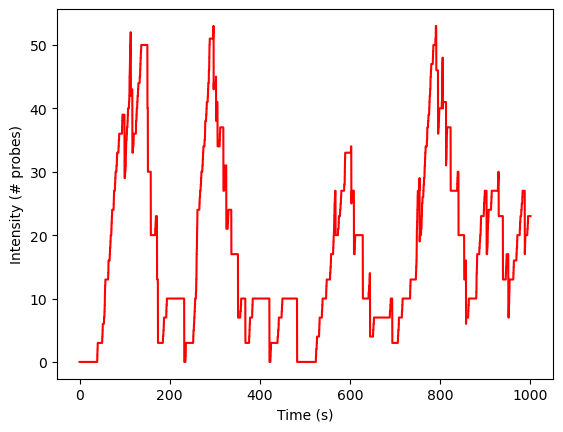

In [92]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')

Text(105, 900, 'alt start')

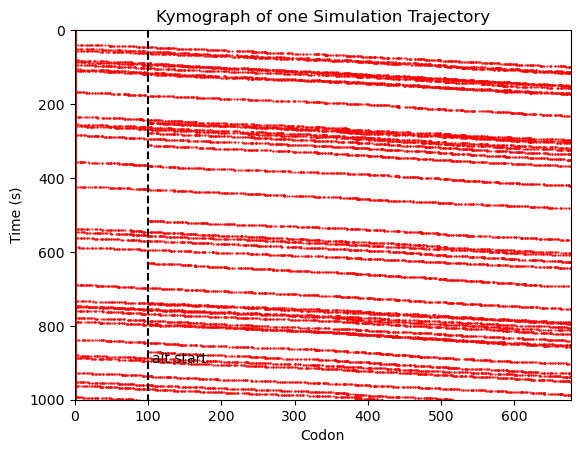

In [93]:
plot_kymograph(soln.ribosome_array[0])
plt.plot([100,100],[0,1000],'k--')
plt.text(105,900,'alt start')

## Frameshifting example

Now lets simulate something more complicated and real. Here is a construct utilizing the HIV frameshift slippery sequence to encode two different fluorescent epitopes, one color in the 0 frame and another in the -1 frame.

![](../docs/images/FSS.png)


This model uses bursting kinetics between two states that determines whether a ribosome enters the -1 frame on a particular codon location. "FSS on" and "FSS off" leading to trains of ribosomes that all have the same color tag.


In [152]:

ken_sequence_frame_0 = '''
ATGAGCACCGCCTCCTCTGGCACAGCCAGTAGTGGGACTGCATCCTCAGGTGCGGGTACCCTGCATGGTTTTTTAGAAGATCTGGCCTTCCCACAAGGGAAGGCCAGGGAATTTTCTTCA
GAGCAGACCAGAGCCAACAGCCGCACCGTTTCTAGAGGACTACAAGGACGACGACGACAAAGGGAAGAACTTTTGTCAAAGAATTATCATCTCGAGAACGAAGTGGCTCGTCTCAAGAAA
GGATTACAAAGACGACGACGACAAGGGGAAGAACTGCTTTCAAAGAATTACCACCTGGAAAACGAGGTCGCGAGACTCAAAAAGAGATTACAAAGACGACGACGACAAGGGGAAGAATTA
CTCAGCAAAAATTATCATCTGGAAAACGAGGTTGCGAGACTCAAAAAGGGACTACAAAGACGACGACGACAAAGCGAAGAACTTTTGTCCAAGAATTATCATCTGGAGAACGAAGTGGCT
CGTCTCAAGAAAGGATTACAAGGACGACGACGACAAGGGGAAGAACTGCTTTCAAAGAATTACCACCTGGAAAATGAGGTGGCTAGACTCAAAAAGGGATTACAAGGACGACGACGACAA
GGGGAGGAACTACTTTCAAAGAATTACCACCTCGAAAACGAAGTGGCTCGACTTAAGAAAGGACTACAAAGACGACGACGACAAGGGGAGGAATTGCTATCGAAAAATTATCATCTTGAG
AACGAAGTTGCTAGGCTCAAAAAGCGATTACAAGGACGACGACGACAAGCGGAAGAATTACTGTCCAAAAATTATCATCTGGAAAATGAGGTGGCGAGACTCAAAAAGGGACTACAAGGA
CGACGACGACAAACCGAGGAACTGCTCTCGAAGAACTATCATCTTGAAAATGAGGTCGCTCGACTCAAAAAGAGATTACAAGGACGACGACGACAAGCAGAAGAGCTATTATCTAAAAAC
TACCACCTCGAAAATGAGGTGGCACGCCTCAAAAAGGGATTACAAAGACGACGACGACAAAAGGAAGAGCTACTATCCAAGAATTATCATCTTGAGAACGAGGTGGCGCGTCTCAAGAAG
CGACTACAAGGACGACGACGACAAAGAGAGGAGTTGCTTAGCAAAAATTATCATTTGGAGAACGAAGTCGCACGACTCAAGAAAACTAGTGGCGGTCATATGGGCGTGCGCAACTGCCTC
TACGGCAATAATATGTCAGGACAACGCGATATCCCCCCTGAAATCGGGGAACAGCCCGAGCAACCACCTTTGGAGGCCCCAGGGGCAGCTGCCCCCGGTGCTGGGCCTAGCCCAGCCGAA
GAGATGGAGACCGAACCGCCTCACAACGAGCCCATCCCCGTCGAGAATGATGGCGAGGCCTGTGGACCCCCAGAGGTCTCCAGACCCAACTTTCAGGTCCTCAACCCGGCATTCAGGGAA
GCTGGAGCCCATGGAAGCTACAGCCCACCTCCTGAGGAAGCAATGCCCTTCGAGGCTGAACAGCCCAGCTTGGGAGGCTTCTGGCCTACACTGGAGCAGCCTGGATTCCCCAGTGGGGTC
CATGCAGGCCTTGAGGCCTTCGGCCCAGCACTCATGGAGCCCGGAGCCTTCAGTGGTGCCAGACCAGGCCTGGGAGGATACAGCCCTCCACCAGAAGAAGCTATGCCCTTTGAGTTTGAC
CAGCCTGCCCAGAGAGGCTGCAGTCAACTTCTCTTACAGGTCCCAGACCTTGCTCCAGGAGGCCCAGGTGCTGCAGGGGTCCCCGGAGCTCCTCCCGAGGAGCCCCAAGCCCTCAGGCCT
GCAAAGGCTGGCTCCAGAGGAGGCTACAGCCCTCCCCCTGAGGAGACTATGCCATTTGAGCTTGATGGAGAAGGATTTGGGGACGACAGCCCACCCCCGGGGCTTTCCCGAGTTATCGCA
CAAGTCGACGGCAGCAGCCAGTTCGCGGCAGTCGCGGCCTCGAGTGCGGTCCGCCTCACTCCCGCCGCGAACGCGCCTCCCCTCTGGGTCCCAGGCGCCATCGGCAGCCCATCCCAAGAG
GCTGTCAGACCTCCTTCTAACTTCACGGGCAGCAGCCCCTGGATGGAGATCTCCGGACCCCCGTTCGAGATTGGCAGCGCCCCCGCTGGGGTCGACGACACTCCCGTCAACATGGACAGC
CCCCCAATCGCGCTTGACGGCCCGCCCATCAAGGTCTCCGGAGCCCCAGATAAGAGAGAGCGAGCAGAGAGACCCCCAGTTGAGGAGGAAGCAGCAGAGATGGAAGGAGCCGCTGATGCC
GCGGAGGGAGGAAAAGTACCCTCTCCGGGGTACGGATCCCCTGCCGCCGGGGCAGCCTCAGCGGATACCGCTGCCAGGGCAGCCCCTGCAGCCCCAGCCGATCCTGACTCCGGGGCAACC
CCAGAAGATCCCGACTCCGGGACAGCACCAGCCGATCCTGACTCCGGGGCATTCGCAGCCGATCCCGACTCCGGGGCAGCCCCTGCCGCCCCAGCCGATCCCGACTCCGGGGCGGCCCCT
GACGCCCCAGCCGATCCCGACTCCGGGGCGGCCCCTGACGCCCCAGCCGATCCAGATGCCGGGGCGGCCCCTGAGGCTCCCGCCGCCCCTGCGGCTGCTGAGACCCGGGCAGCCCATGTC
GCCCCAGCTGCGCCAGACGCAGGGGCTCCCACTGCCCCAGCCGCTTCTGCCACCCGGGCAGCCCAAGTCCGCCGGGCGGCCTCTGCAGCCCCTGCCTCCGGGGCCAGACGCAAGATCCAT
CTCAGACCCCCCAGCCCCGAGATCCAGGCTGCCGATCCGCCTACTCCGCGGCCTACTCGCGCGTCTGCCTGGCGGGGCAAGTCCGAGAGCAGCCGCGGCCGCCGCGTGTACTACGATGAA
GGGGTGGCCAGCAGCGACGATGACTCCAGCGGAGACGAGTCCGACGATGGGACCTCCGGATGCCTCCGCTGGTTTCAGCATCGGCGAAATCGCCGCCGCCGAAAGCCCCAGCGCAACTTA
CTCCGCAACTTTCTCGTGCAAGCCTTCGGGGGCTGCTTCGGTCGATCTGAGAGTCCCCAGCCCAAAGCCTCGCGCTCTCTCAAGGTCAAGAAGGTACCCCTGGCGGAGAAGCGCAGACAG
ATGCGCAAAGAAGCCCTGGAGAAGCGGGCCCAGAAGCGCGCAGAGAAGAAACGCAGTAAGCTCATCGACAAACAACTCCAGGACGAAAAGATGGGCTACATGTGTACGCACCGCCTGCTG
CTTCTAGGCTAG
'''

ken_sequence_frame_0 = ''.join(ken_sequence_frame_0.split('\n'))
aa_seq1 = rsnp.seqmanip.nt2aa(ken_sequence_frame_0)

ken_sequence_frame_1 = '''ATGAGCACCGCCTCCTCTGGCACAGCCAGTAGTGGGACTGCATCCTCAGGTGCGGGTACCCTGCATGGTTTTTTAGGGAAGATCTGGCCTTCCCACAAGGGAAGGCCAGGGAATTTTCTTCAGAGCAGACCAGAGCCAACAGCCGCACCGTTTCTAGAGGACTACAAGGACGACGACGACAAAGGGAAGAACTTTTGTCAAAGAATTATCATCTCGAGAACGAAGTGGCTCGTCTCAAGAAAGGATTACAAAGACGACGACGACAAGGGGAAGAACTGCTTTCAAAGAATTACCACCTGGAAAACGAGGTCGCGAGACTCAAAAAGAGATTACAAAGACGACGACGACAAGGGGAAGAATTACTCAGCAAAAATTATCATCTGGAAAACGAGGTTGCGAGACTCAAAAAGGGACTACAAAGACGACGACGACAAAGCGAAGAACTTTTGTCCAAGAATTATCATCTGGAGAACGAAGTGGCTCGTCTCAAGAAAGGATTACAAGGACGACGACGACAAGGGGAAGAACTGCTTTCAAAGAATTACCACCTGGAAAATGAGGTGGCTAGACTCAAAAAGGGATTACAAGGACGACGACGACAAGGGGAGGAACTACTTTCAAAGAATTACCACCTCGAAAACGAAGTGGCTCGACTTAAGAAAGGACTACAAAGACGACGACGACAAGGGGAGGAATTGCTATCGAAAAATTATCATCTTGAGAACGAAGTTGCTAGGCTCAAAAAGCGATTACAAGGACGACGACGACAAGCGGAAGAATTACTGTCCAAAAATTATCATCTGGAAAATGAGGTGGCGAGACTCAAAAAGGGACTACAAGGACGACGACGACAAACCGAGGAACTGCTCTCGAAGAACTATCATCTTGAAAATGAGGTCGCTCGACTCAAAAAGAGATTACAAGGACGACGACGACAAGCAGAAGAGCTATTATCTAAAAACTACCACCTCGAAAATGAGGTGGCACGCCTCAAAAAGGGATTACAAAGACGACGACGACAAAAGGAAGAGCTACTATCCAAGAATTATCATCTTGAGAACGAGGTGGCGCGTCTCAAGAAGCGACTACAAGGACGACGACGACAAAGAGAGGAGTTGCTTAGCAAAAATTATCATTTGGAGAACGAAGTCGCACGACTCAAGAAAACTAGTGGCGGTCATATGGGCGTGCGCAACTGCCTCTACGGCAATAATATGTCAGGACAACGCGATATCCCCCCTGAAATCGGGGAACAGCCCGAGCAACCACCTTTGGAGGCCCCAGGGGCAGCTGCCCCCGGTGCTGGGCCTAGCCCAGCCGAAGAGATGGAGACCGAACCGCCTCACAACGAGCCCATCCCCGTCGAGAATGATGGCGAGGCCTGTGGACCCCCAGAGGTCTCCAGACCCAACTTTCAGGTCCTCAACCCGGCATTCAGGGAAGCTGGAGCCCATGGAAGCTACAGCCCACCTCCTGAGGAAGCAATGCCCTTCGAGGCTGAACAGCCCAGCTTGGGAGGCTTCTGGCCTACACTGGAGCAGCCTGGATTCCCCAGTGGGGTCCATGCAGGCCTTGAGGCCTTCGGCCCAGCACTCATGGAGCCCGGAGCCTTCAGTGGTGCCAGACCAGGCCTGGGAGGATACAGCCCTCCACCAGAAGAAGCTATGCCCTTTGAGTTTGACCAGCCTGCCCAGAGAGGCTGCAGTCAACTTCTCTTACAGGTCCCAGACCTTGCTCCAGGAGGCCCAGGTGCTGCAGGGGTCCCCGGAGCTCCTCCCGAGGAGCCCCAAGCCCTCAGGCCTGCAAAGGCTGGCTCCAGAGGAGGCTACAGCCCTCCCCCTGAGGAGACTATGCCATTTGAGCTTGATGGAGAAGGATTTGGGGACGACAGCCCACCCCCGGGGCTTTCCCGAGTTATCGCACAAGTCGACGGCAGCAGCCAGTTCGCGGCAGTCGCGGCCTCGAGTGCGGTCCGCCTCACTCCCGCCGCGAACGCGCCTCCCCTCTGGGTCCCAGGCGCCATCGGCAGCCCATCCCAAGAGGCTGTCAGACCTCCTTCTAACTTCACGGGCAGCAGCCCCTGGATGGAGATCTCCGGACCCCCGTTCGAGATTGGCAGCGCCCCCGCTGGGGTCGACGACACTCCCGTCAACATGGACAGCCCCCCAATCGCGCTTGACGGCCCGCCCATCAAGGTCTCCGGAGCCCCAGATAAGAGAGAGCGAGCAGAGAGACCCCCAGTTGAGGAGGAAGCAGCAGAGATGGAAGGAGCCGCTGATGCCGCGGAGGGAGGAAAAGTACCCTCTCCGGGGTACGGATCCCCTGCCGCCGGGGCAGCCTCAGCGGATACCGCTGCCAGGGCAGCCCCTGCAGCCCCAGCCGATCCTGACTCCGGGGCAACCCCAGAAGATCCCGACTCCGGGACAGCACCAGCCGATCCTGACTCCGGGGCATTCGCAGCCGATCCCGACTCCGGGGCAGCCCCTGCCGCCCCAGCCGATCCCGACTCCGGGGCGGCCCCTGACGCCCCAGCCGATCCCGACTCCGGGGCGGCCCCTGACGCCCCAGCCGATCCAGATGCCGGGGCGGCCCCTGAGGCTCCCGCCGCCCCTGCGGCTGCTGAGACCCGGGCAGCCCATGTCGCCCCAGCTGCGCCAGACGCAGGGGCTCCCACTGCCCCAGCCGCTTCTGCCACCCGGGCAGCCCAAGTCCGCCGGGCGGCCTCTGCAGCCCCTGCCTCCGGGGCCAGACGCAAGATCCATCTCAGACCCCCCAGCCCCGAGATCCAGGCTGCCGATCCGCCTACTCCGCGGCCTACTCGCGCGTCTGCCTGGCGGGGCAAGTCCGAGAGCAGCCGCGGCCGCCGCGTGTACTACGATGAAGGGGTGGCCAGCAGCGACGATGACTCCAGCGGAGACGAGTCCGACGATGGGACCTCCGGATGCCTCCGCTGGTTTCAGCATCGGCGAAATCGCCGCCGCCGAAAGCCCCAGCGCAACTTACTCCGCAACTTTCTCGTGCAAGCCTTCGGGGGCTGCTTCGGTCGATCTGAGAGTCCCCAGCCCAAAGCCTCGCGCTCTCTCAAGGTCAAGAAGGTACCCCTGGCGGAGAAGCGCAGACAGATGCGCAAAGAAGCCCTGGAGAAGCGGGCCCAGAAGCGCGCAGAGAAGAAACGCAGTAAGCTCATCGACAAACAACTCCAGGACGAAAAGATGGGCTACATGTGTACGCACCGCCTGCTGCTTCTAG'''
aa_seq2 = rsnp.seqmanip.nt2aa(ken_sequence_frame_1)

matching_index = 0
for i in range(len(max(ken_sequence_frame_0, ken_sequence_frame_1))):
    if ken_sequence_frame_0[:i] == ken_sequence_frame_1[:i]:
        matching_index = i


full_construct = ken_sequence_frame_0 + ken_sequence_frame_1
kelong = rsnp.propf.get_k( full_construct, .03, 3, 0)[1:]
kelong[1083] = 0  # frame one stop codon
ki = .0244
kon = 9.6e-5
koff = 1.3e-4
kpause_fss_off = .0234
kelong[24] = 1/((1/kelong[24]) + (1/kpause_fss_off))
kpause_fss_on = .0139
length = 1083
kout_frame0 = 3
kout_frame1 = 3
frameshift_location = 25

poi_0 = rsnp.seqmanip.seq_to_CDS_obj(ken_sequence_frame_0)
poi_1 = rsnp.seqmanip.seq_to_CDS_obj(ken_sequence_frame_1)

flagtags = poi_1['0'][0].tag_epitopes
suntags = poi_0['0'][0].tag_epitopes

probe_locations = np.zeros([2,len(kelong)], dtype=np.intc  )
probe_locations[0,flagtags['T_Flag']] = 1
probe_locations[1,np.array([suntags['T_SunTag']])+length   ] = 1


# Make the mRNA object
poi = rsnp.seqmanip.seq_to_CDS_obj(ken_sequence_frame_0) # convert a given sequence to a protein of interest object
mRNA = poi['0'][0]                              # pull out the main open reading frame
mRNA_length = len(mRNA.kelong)                  # get the length of the mRNA
mRNA.generate_3frame_tags()                     # call to generate all open reading frames tags

model = rsnp.tasep_model(mRNA,'FSS') # model object
# Make the kelong mat (manually adding an extra location that is equal to zero, so particles dont run over the simulation)
kelong_mat = np.zeros([3, mRNA_length+1])
kelong_mat[0, :-1] = rsnp.propf.get_k(mRNA.nt_seq, ki, 3, 3)[1:-1]
kelong_mat[1, :-2] = rsnp.propf.get_k(mRNA.nt_seq[1:-2], .1, 3, 3)[1:-1]
#kelong_mat[2, :-2] = rsnp.propf.get_k(mRNA.nt_seq[2:-1], .1, 3, 3)[1:-1]
kelong_mat[0, -2] = 0
kelong_mat[1,:24] = 0
kelong_mat[1,24] = kpause_fss_on # PAUSING DUE TO FSS SEQUENCE
kelong_mat[0,24] = kpause_fss_off
model._kelong_mat = kelong_mat #override the current kelongation mat

############ parameters ####################
k_fss = 1e4
parameters = [ki, kout_frame0, kout_frame1, kon, koff, k_fss]

############ resources ####################
# N/A
############ states ####################

# we need two states for the mRNA FSS turning on and off:
model.add_states(2, state0=[1,0], names=['off','on'])

############ RXNS ####################


# ribosomal initiation
footprint = 9
# first add the reaction, in this case, we want a lattice reaction at the first
# location for a ribosome to bind (excluded)

init = lambda k,t,p,ke,o,l,pr,s,r,nr: ~np.any(l[0:0+footprint])*k[0]
model.add_lattice_reaction(init, parameters, rxn_name='intiation', exclusion=1, frame=0, loc=0, dexist=1,)

# Now we need a reaction for ribosomes to leave the lattice frame 0 at the end (location 1083)
leave_f0 = lambda k,t,p,ke,o,l,pr,s,r,nr: l[1083]*k[1] #(lattice location 1084 = 1) * parameter
model.add_lattice_reaction(leave_f0, parameters, rxn_name='termination_frame0', exclusion=0, frame=0, loc=1083, dexist=-1,)

# Now we need a reaction for ribosomes to leave the lattice frame 1 at the end (location 1083)
leave_f1 = lambda k,t,p,ke,o,l,pr,s,r,nr: l[1083]*k[2] #(lattice location 1084 = 1) * parameter
model.add_lattice_reaction(leave_f1, parameters, rxn_name='termination_frame1', exclusion=0, frame=1, loc=1083, dexist=-1,)


############# state RXNS ##############

# mRNA turning on
mRNA_on = lambda k,t,p,ke,o,l,pr,s,r,nr: s[0]*k[3]
model.add_state_reaction(mRNA_on, parameters, rxn_name='mRNA on', inds=[0,1],dstates=[-1, 1])

# mRNA turning off

mRNA_off = lambda k,t,p,ke,o,l,pr,s,r,nr: s[1]*k[4]
model.add_state_reaction(mRNA_off, parameters, rxn_name='mRNA off', inds=[0,1],dstates=[1, -1])


# DEFAULT STEPPING OF ELONGATION USING THE ELONGATION MATRIX
                                                # agent frame, agent location
elong_step = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(elong_step, parameters, rxn_name='elongation', exclusion=1, dloc=1) 

# FSS
# JUMP +1 frame if greater than or equal to frameshift location, on frame 0, state = on
FSS = lambda k,t,p,ke,o,l,pr,s,r,nr: [k[5]*(p[i,2] == 0)*(p[i,3] >= frameshift_location)*s[1] for i in range(nr)]
model.add_ribosome_reaction(FSS, parameters, rxn_name='FSS', exclusion=1, dframe=1, dloc=0) 



#initial state
model._state_arr0[0] = 1 # FSS off
# finally specify which reactions are ribosome specific
model._ribosome_reactions = [5,6]
model._constant_reactions = [0,1,2,3,4]

model._lattice_arr0 = np.zeros([model._length+1], dtype=int)

In [153]:
t = np.linspace(0,10000,10001)
soln = rsnp.solver.solve_ssa(model, t, n_traj = 1, seed=305)

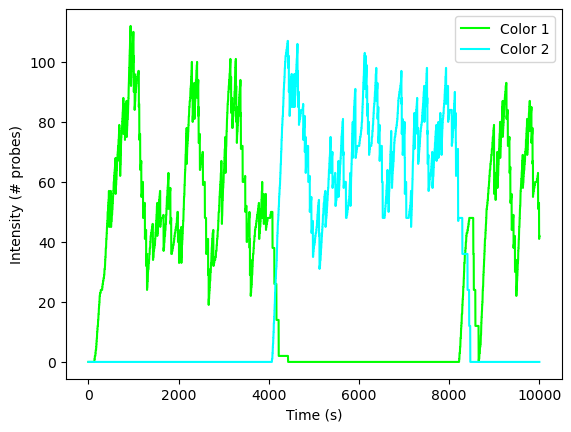

In [154]:
plt.plot(soln.t, soln.intensity_arr[0,:,0], color='#00FF00')
plt.plot(soln.t, soln.intensity_arr[0,:,1], color='#00FFFF')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')
plt.legend(['Color 1', 'Color 2'])

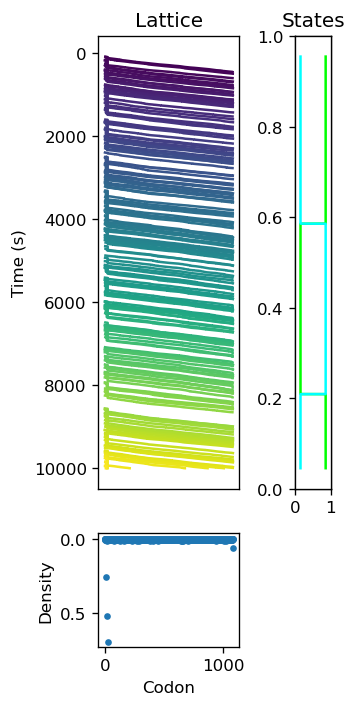

In [169]:

fig = plt.figure(tight_layout=True, dpi=120, figsize=(3,6))
gs = gridspec.GridSpec(2, 2, width_ratios=(4,1), height_ratios=(4, 1),)
kym = fig.add_subplot(gs[0,0])
intense = fig.add_subplot(gs[0, 1])
profile = fig.add_subplot(gs[1,0])
states = fig.add_subplot(gs[0,1])

un = len(np.unique(soln.ribosome_array[0][:,:,0]))
for i in np.unique(soln.ribosome_array[0][:,:,0]):
    if i != 0:
        rib_traj = soln.ribosome_array[0][soln.ribosome_array[0][:,:,0]==i]
        kym.plot( rib_traj[:,3], np.where(soln.ribosome_array[0][:,:,0]==i)[0], color=cm.viridis(i/un))

kym.set_ylabel('Time (s)')
kym.invert_yaxis()
kym.set_title('Lattice')
kym.set_xticks([])

#intense.plot(soln.I[0], soln.t)
#intense.invert_yaxis()
#intense.set_yticks([])
#intense.set_xlabel('I')

states.plot(soln.state_array[0][:,0], soln.t, color='#00FF00')
states.plot(soln.state_array[0][:,1], soln.t, color='#00FFFF')
states.set_xlim([-.2,1.2])
states.invert_yaxis()
states.set_yticks([])
states.set_xticks([])
states.set_title('States')


profile.plot(np.mean(soln.lattice_arr[0],axis=0),'.')
profile.set_ylabel('Density')
profile.set_xlabel('Codon')
profile.invert_yaxis()

## Backwards motion example model

Here is a model where we allow multiple types of particles, in this case one that moves forward and one that moves backwards. To prevent an entire traffice jam the ribosomes have a chance to drop off if there is something blocking their forward motion.


In [131]:

example_mRNA = '''ATGGCGAACCTTGGCTGCTGGATGCTGGTTCTCTTTGTGGCCACATGGAGTGACCTGGGC
                    CTCTGCAAGAAGCGCCCGAAGCCTGGAGGATGGAACACTGGGGGCAGCCGATACCCGGGG
                    CAGGGCAGCCCTGGAGGCAACCGCTACCCACCTCAGGGCGGTGGTGGCTGGGGGCAGCCT
                    CATGGTGGTGGCTGGGGGCAGCCTCATGGTGGTGGCTGGGGGCAGCCCCATGGTGGTGGC
                    TGGGGACAGCCTCATGGTGGTGGCTGGGGTCAAGGAGGTGGCACCCACAGTCAGTGGAAC
                    AAGCCGAGTAAGCCAAAAACCAACATGAAGCACATGGCTGGTGCTGCAGCAGCTGGGGCA
                    GTGGTGGGGGGCCTTGGCGGCTACATGCTGGGAAGTGCCATGAGCAGGCCCATCATACAT
                    TTCGGCAGTGACTATGAGGACCGTTACTATCGTGAAAACATGCACCGTTACCCCAACCAA
                    GTGTACTACAGGCCCATGGATGAGTACAGCAACCAGAACAACTTTGTGCACGACTGCGTC
                    AATATCACAATCAAGCAGCACACGGTCACCACAACCACCAAGGGGGAGAACTTCACCGAG
                    ACCGACGTTAAGATGATGGAGCGCGTGGTTGAGCAGATGTGTATCACCCAGTACGAGAGG
                    GAATCTCAGGCCTATTACCAGAGAGGATCGAGCATGGTCCTCTTCTCCTCTCCACCTGTG
                    ATCCTCCTGATCTCTTTCCTCATCTTCCTGATAGTGGGATGA'''.replace('\n','').replace(' ','')



# Make the mRNA object
poi = rsnp.seqmanip.seq_to_CDS_obj(example_mRNA) # convert a given sequence to a protein of interest object
mRNA = poi['0'][0]                              # pull out the main open reading frame
mRNA_length = len(mRNA.kelong)                  # get the length of the mRNA
mRNA.generate_3frame_tags()                     # call to generate all open reading frames

# manually adding epitopes for two colors
mRNA.multiframe_epitopes[0] = {'T_Flag': [1, 10, 19, 195, 205, 217, 227, 299, 308, 317], 'T_HA':[400,410,420,430]}


model = rsnp.tasep_model(mRNA, 'tsixxist') # model object

## overwite the default kelongation matrix 
kelong_mat = np.zeros([3, mRNA_length])
kelong_mat[0, :-1] = 4 
kelong_mat[1, :-1] = 4
kelong_mat[2, :-1] = 4
kelong_mat[0, -1] = 0 # cant step out of 0 frame
kelong_mat[1,0] = 0 # cant step out of 1 frame
kelong_mat[1,-1] = 4 # cant step out of 1 frame


model._kelong_mat = kelong_mat #override the current kelongation mat
model._probe_mat = np.zeros([3, mRNA_length])

footprint = 30
model.particle_size = 30
last_codon = mRNA_length-1

initiation_tsix = .08
initiation_xist = .08

termination_tsix = 10
termination_xist = 10

dropoff_tsix = .01
dropoff_xist = .01 

# histone bursting
k_xoff = .5
k_xon = .5
k_toff = .5
k_ton = .5

# labelling reactions, labeling the particles
klabel = 10000

parameters = [initiation_xist, initiation_tsix, k_xoff, k_xon, k_toff, k_ton, klabel, termination_tsix, termination_xist, dropoff_tsix, dropoff_xist]
# k is the parameters, t = timepoint, p = ribosome_array/array, occupation array, lattice array, probe matrix, state matrix
# r = resources, nr = number of ribosomes
# Check the docstring!

# Initiation rate of XIST going forwards
init_xist = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]*s[0]
model.add_lattice_reaction(init_xist, parameters, rxn_name = 'initiation_xist', frame=0, loc=0, dexist=1,)

# Intiation rate of TSIX going backwards
init_tsix = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[last_codon-footprint:last_codon+1]))*k[1]*s[1]
model.add_lattice_reaction(init_tsix, parameters, rxn_name = 'initiation_tsix', frame=1, loc=last_codon, dexist=1,)

# Termination rate of XIST going forwards
term_xist = lambda k,t,p,ke,o,l,pr,s,r,nr: k[7]*l[last_codon]
model.add_lattice_reaction(term_xist, parameters, rxn_name = 'term_xist', frame=0, loc=last_codon, dexist=-1,)

# Termination rate of TSIX going backwards
term_tsix = lambda k,t,p,ke,o,l,pr,s,r,nr: k[8]*l[0]
model.add_lattice_reaction(term_tsix, parameters, rxn_name = 'term_tsix', frame=1, loc=0, dexist=-1,)


model.add_states(2, state0=[0,0], names=['xist_histone','tsix_histone'])
####### HISTONES ###########
# state = [xist on, tsix on]
# histone turning off at Xist
histone_xist_off = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[0]==1)*k[2]
model.add_state_reaction(histone_xist_off, parameters, rxn_name = 'histone_xist_off', inds=[0], dstates=[-1])

histone_xist_on = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[0]==0)*k[3]
model.add_state_reaction(histone_xist_on, parameters, rxn_name = 'histone_xist_on', inds=[0], dstates=[1])

# state = [xist on, tsix on]
# histone turning off at tsix
histone_tsix_off = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[1]==1)*k[4]
model.add_state_reaction(histone_tsix_off, parameters, rxn_name = 'histone_xist_off', inds=[1], dstates=[-1])

histone_tsix_on = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[1]==0)*k[5]
model.add_state_reaction(histone_tsix_on, parameters, rxn_name = 'histone_xist_on', inds=[1], dstates=[1])


# SAME RATE WORKS BOTH WAYS FOR DNA SINCE NUCLEOTIDES ARE ADDED ONE AT A TIME
                                                # agent frame, agent location
step_forward = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 0)*(ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(step_forward, parameters, rxn_name='step forwards', exclusion=1, dloc=1) 

step_backwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 1)*(ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]-footprint:p[i,3]-1])) for i in range(nr)]
model.add_ribosome_reaction(step_backwards, parameters, rxn_name='step backwards', exclusion=1, dloc=-1) 

drop_off_forwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 0)*(l[p[i,3]+1:p[i,3]+footprint+3].any())*k[9] for i in range(nr)]
model.add_ribosome_reaction(drop_off_forwards, parameters, rxn_name='drop forwards', exclusion=1, dexist=-1) 

drop_off_backwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 1)*(l[p[i,3]-footprint:p[i,3]-3].any())*k[10] for i in range(nr)]
model.add_ribosome_reaction(drop_off_backwards, parameters, rxn_name='drop backwards', exclusion=1, dexist=-1) 


# finally specify which reactions are ribosome specific, this should be automated in the future
model._ribosome_reactions = [8,9,10,11]
model._constant_reactions = [0,1,2,3,4,5,6,7]
model._lattice_arr0 = np.zeros([model._length], dtype=int)
model._state_arr0 = np.array([0,0],dtype=int) # states are always going to start OFF, must burn this in!

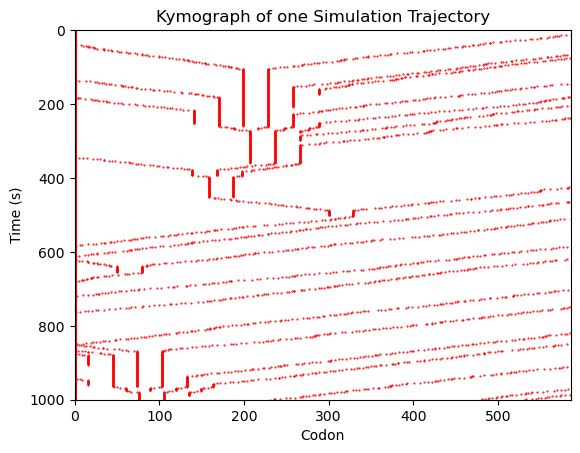

In [135]:
t = np.linspace(0,1000,1001)
soln = rsnp.solver.solve_ssa(model, t)
plot_kymograph(soln.ribosome_array[0])